# Logistic Regression Model: Binary Classification of Nottingham Prognostic Index (NPI)

**Objective:** Classify patients into low- vs. high-risk based on NPI (threshold=3.4) using gene expression and mutation data from METABRIC.

In [1]:
# Set up and imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    classification_report
)

In [2]:
# Load and prepare data
print("Loading METABRIC dataset...")
df = pd.read_csv('METABRIC_RNA_Mutation.csv')
print(f"Dataset shape: {df.shape}")

# Use NPI column for binary classification
target = 'nottingham_prognostic_index'
df['NPI_binary'] = (df[target] > 3.4).astype(int)
print("NPI binary distribution:")
print(df['NPI_binary'].value_counts())

Loading METABRIC dataset...
Dataset shape: (1904, 693)
NPI binary distribution:
NPI_binary
1    1264
0     640
Name: count, dtype: int64


<ipython-input-2-1d6615084558>:3: DtypeWarning: Columns (678,688,690,692) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('METABRIC_RNA_Mutation.csv')


In [3]:
# Identify numeric columns to ensure we only use numeric gene expression data
print("\nExtracting numeric gene expression features only...")
numeric_columns = df.select_dtypes(include=['number']).columns
print(f"Number of numeric columns: {len(numeric_columns)}")

# Identify mutation columns (they typically end with '_mut')
mutation_columns = [col for col in df.columns if col.endswith('_mut')]
print(f"Number of mutation columns: {len(mutation_columns)}")

# Determine the range of gene expression columns
# Based on the notebook, gene expression data is between columns -662 and -173
gene_expr_start = len(df.columns) - 662  # First gene expression column index
gene_expr_end = len(df.columns) - len(mutation_columns)  # Last gene expression column index

# Extract only gene expression data, ensuring it's numeric only
X_expr = df.iloc[:, gene_expr_start:gene_expr_end].select_dtypes(include=['number'])
print(f"Gene expression feature matrix shape: {X_expr.shape}")
y = df['NPI_binary']


Extracting numeric gene expression features only...
Number of numeric columns: 504
Number of mutation columns: 173
Gene expression feature matrix shape: (1904, 488)


# Data Preprocessing

In [4]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_expr, y, test_size=0.2, random_state=42, stratify=y)

# Create a preprocessing and modeling pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Train Logistic Regression Models


In [5]:
# Define evaluation function
def evaluate(y_true, y_pred, y_proba, label):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba)
    print(f"--- {label} ---")
    print(f"Accuracy: {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall: {rec:.3f}")
    print(f"F1-score: {f1:.3f}")
    print(f"ROC-AUC: {roc_auc:.3f}\n")
    return acc, prec, rec, f1, roc_auc

# 1. Train baseline model
print("\n1. BASELINE MODEL")
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:,1]
baseline_metrics = evaluate(y_test, y_pred, y_proba, 'Baseline Gene Expression Model')

# 2. Hyperparameter tuning with cross-validation
print("2. HYPERPARAMETER TUNING")
# Set up parameter grid
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear'],
    'classifier__class_weight': [None, 'balanced']
}

# Grid search with cross-validation
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1',
    verbose=1
)
grid_search.fit(X_train, y_train)

# Display best parameters
best_model = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.3f}")

# Evaluate best model
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:,1]
best_metrics = evaluate(y_test, y_pred_best, y_proba_best, 'Tuned Gene Expression Model')



1. BASELINE MODEL
--- Baseline Gene Expression Model ---
Accuracy: 0.688
Precision: 0.762
Recall: 0.771
F1-score: 0.766
ROC-AUC: 0.699

2. HYPERPARAMETER TUNING
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best CV score: 0.808
--- Tuned Gene Expression Model ---
Accuracy: 0.719
Precision: 0.770
Recall: 0.822
F1-score: 0.795
ROC-AUC: 0.755



In [6]:
# 3. Feature selection
print("3. FEATURE SELECTION")
# Feature selection using L1 regularization
selector = SelectFromModel(
    LogisticRegression(C=0.01, penalty='l1', solver='liblinear', max_iter=1000)
)
# Apply scaler first - use the same scaler instance for both train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

selector.fit(X_train_scaled, y_train)
selected_features = selector.get_support()
n_selected = np.sum(selected_features)
print(f"Number of selected features: {n_selected} out of {X_train.shape[1]}")

# Apply feature selection
X_train_selected = selector.transform(X_train_scaled)
X_test_selected = selector.transform(X_test_scaled)

# Train model with selected features
selected_model = LogisticRegression(max_iter=1000)
selected_model.fit(X_train_selected, y_train)
y_pred_selected = selected_model.predict(X_test_selected)
y_proba_selected = selected_model.predict_proba(X_test_selected)[:,1]
selected_metrics = evaluate(y_test, y_pred_selected, y_proba_selected, 'Selected Features Model')

# 4. Cross-validation for more reliable performance estimation
print("4. CROSS-VALIDATION PERFORMANCE")
cv_results = cross_validate(
    best_model,
    X_train, y_train,
    cv=5,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
)

print("Cross-validation results:")
for metric in ['test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_roc_auc']:
    scores = cv_results[metric]
    print(f"{metric}: {np.mean(scores):.3f} ± {np.std(scores):.3f}")

# 5. Find optimal threshold for balancing precision and recall
print("\n5. OPTIMAL THRESHOLD FOR PRECISION-RECALL BALANCE")
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_best)

# Find threshold where precision equals recall (balanced)
i = np.argmin(np.abs(precisions[:-1] - recalls[:-1]))
optimal_threshold = thresholds[i]
print(f"Optimal threshold: {optimal_threshold:.3f}")


3. FEATURE SELECTION
Number of selected features: 8 out of 488
--- Selected Features Model ---
Accuracy: 0.706
Precision: 0.747
Recall: 0.842
F1-score: 0.792
ROC-AUC: 0.751

4. CROSS-VALIDATION PERFORMANCE
Cross-validation results:
test_accuracy: 0.736 ± 0.032
test_precision: 0.781 ± 0.021
test_recall: 0.838 ± 0.029
test_f1: 0.808 ± 0.024
test_roc_auc: 0.789 ± 0.041

5. OPTIMAL THRESHOLD FOR PRECISION-RECALL BALANCE
Optimal threshold: 0.564


# Visualizations/ Analysis

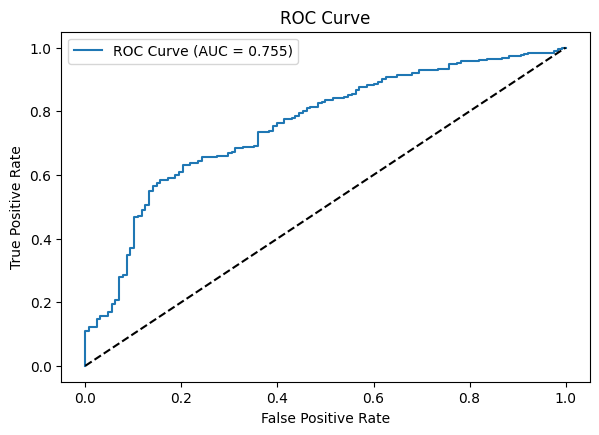

In [7]:
plt.figure(figsize=(15, 10))

# ROC Curve
plt.subplot(2, 2, 1)
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_proba_best):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

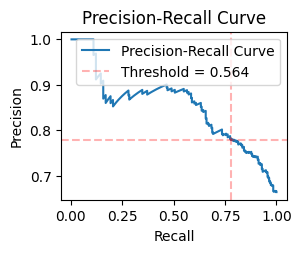

In [8]:
# Precision-Recall Curve
plt.subplot(2, 2, 2)
plt.plot(recalls[:-1], precisions[:-1], label='Precision-Recall Curve')
plt.axvline(recalls[i], color='r', linestyle='--', alpha=0.3, label=f'Threshold = {optimal_threshold:.3f}')
plt.axhline(precisions[i], color='r', linestyle='--', alpha=0.3)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

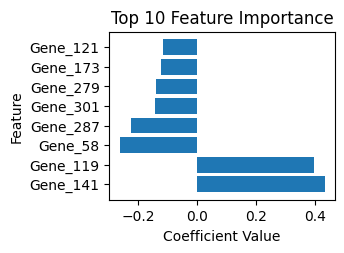

In [12]:
# Feature Importance Plot

# Get feature indices
feature_indices = np.where(selected_features)[0]

# Get feature names if available, otherwise use indices
feature_names = [f"Gene_{i}" for i in feature_indices]

# Get coefficients
coefficients = selected_model.coef_[0]

# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients})

# Sort by absolute coefficient value
feature_importance['AbsCoef'] = np.abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values('AbsCoef', ascending=False).head(20)

if n_selected < 50:
    plt.subplot(2, 2, 3)
    top_features = feature_importance.head(10)
    plt.barh(top_features['Feature'], top_features['Coefficient'])
    plt.xlabel('Coefficient Value')
    plt.ylabel('Feature')
    plt.title('Top 10 Feature Importance')

Visualizations saved to 'gene_expression_model_results.png'


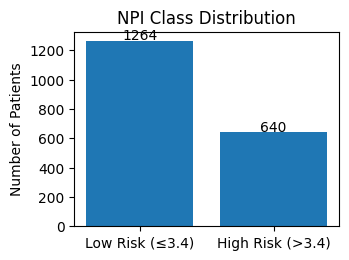

In [13]:
# Class Distribution
plt.subplot(2, 2, 4)
class_counts = y.value_counts()
plt.bar(['Low Risk (≤3.4)', 'High Risk (>3.4)'], class_counts.values)
plt.ylabel('Number of Patients')
plt.title('NPI Class Distribution')
for i, count in enumerate(class_counts.values):
    plt.text(i, count + 10, str(count), ha='center')

plt.tight_layout()
plt.savefig('gene_expression_model_results.png')
print("Visualizations saved to 'gene_expression_model_results.png'")

In [14]:
# 8. Model comparison
print("\n8. MODEL COMPARISON SUMMARY")
models = [
    "Baseline Gene Expression",
    "Tuned Gene Expression",
    "Selected Features"
]

metrics = np.array([
    baseline_metrics,
    best_metrics,
    selected_metrics
])

metrics_df = pd.DataFrame(
    metrics,
    columns=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'],
    index=models
)

print(metrics_df)

# Save the dataframe as CSV
metrics_df.to_csv('gene_expression_model_performance.csv')



8. MODEL COMPARISON SUMMARY
                          Accuracy  Precision    Recall        F1   ROC-AUC
Baseline Gene Expression  0.687664   0.761719  0.770751  0.766208  0.698586
Tuned Gene Expression     0.719160   0.770370  0.822134  0.795411  0.755435
Selected Features         0.706037   0.747368  0.841897  0.791822  0.751112


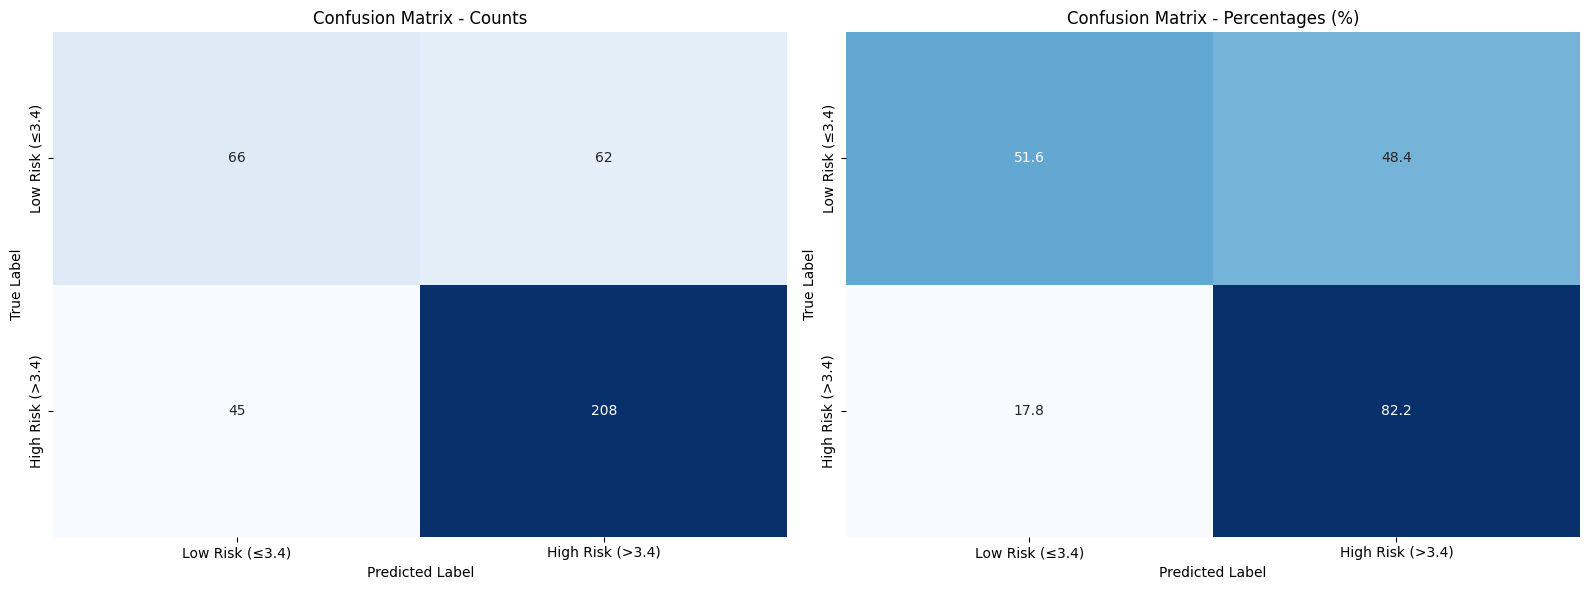

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Best model is fine-tuned model
y_pred = best_model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Create a figure with two subplots side by side
plt.figure(figsize=(16, 6))

# Plot 1: Counts confusion matrix
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Counts')
plt.xticks([0.5, 1.5], ['Low Risk (≤3.4)', 'High Risk (>3.4)'])
plt.yticks([0.5, 1.5], ['Low Risk (≤3.4)', 'High Risk (>3.4)'])

# Plot 2: Percentages confusion matrix (normalized by true label)
plt.subplot(1, 2, 2)
# Calculate percentages by row (true label)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Percentages (%)')
plt.xticks([0.5, 1.5], ['Low Risk (≤3.4)', 'High Risk (>3.4)'])
plt.yticks([0.5, 1.5], ['Low Risk (≤3.4)', 'High Risk (>3.4)'])

plt.tight_layout()
plt.savefig('confusion_matrix_tuned_model.png')
plt.show()


In [16]:
# 9. Final recommended model
print("\n9. FINAL RECOMMENDED MODEL")
# Determine best model based on F1 score (balances precision and recall)
best_model_index = metrics_df['F1'].idxmax()
print(f"Best model: {best_model_index}")
print(f"Performance: {metrics_df.loc[best_model_index].to_dict()}")

if best_model_index == "Tuned Gene Expression":
    print("Hyperparameters:", grid_search.best_params_)

print("1. The optimal threshold of {:.3f} balances precision and recall".format(optimal_threshold))
print("2. Cross-validation shows model stability of {:.1f}% ± {:.1f}% accuracy".format(
    np.mean(cv_results['test_accuracy'])*100, np.std(cv_results['test_accuracy'])*100))
print("3. Consider the F1 score for overall balanced performance")


9. FINAL RECOMMENDED MODEL
Best model: Tuned Gene Expression
Performance: {'Accuracy': 0.7191601049868767, 'Precision': 0.7703703703703704, 'Recall': 0.8221343873517787, 'F1': 0.7954110898661568, 'ROC-AUC': 0.7554347826086958}
Hyperparameters: {'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
1. The optimal threshold of 0.564 balances precision and recall
2. Cross-validation shows model stability of 73.6% ± 3.2% accuracy
3. Consider the F1 score for overall balanced performance
